# Нужно сравнить методы снижения размерности


In [1]:
%pip install umap-learn trimap pacmap phate scikit-learn seaborn pandas numpy

  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
     ---------------------------------------- 41.3/41.3 MB 7.9 MB/s eta 0:00:00
     ---------------------------------------- 78.4/78.4 KB 4.3 MB/s eta 0:00:00
     ---------------------------------------- 2.7/2.7 MB 9.7 MB/s eta 0:00:00
     ---------------------------------------- 8.2/8.2 MB 9.7 MB/s eta 0:00:00
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
     -------------------------------------- 510.1/510.1 KB 8.1 MB/s eta 0:00:00
     -------------------------------------- 349.3/349.3 KB 7.2 MB/s eta 0:00:00
     ---------------------------------------- 1.6/1.6 MB 9.9 MB/s eta 0:00:00
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
  Using cached

You should consider upgrading via the 'e:\projects\psu\eda_2\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import pairwise_distances

from sklearn.manifold import TSNE
import umap
import trimap
import pacmap
import phate

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## Загрузка данных

In [3]:
# Датасет 1 Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names
print(X_iris.shape, np.unique(y_iris))

(150, 4) [0 1 2]


In [17]:
df = pd.read_csv('./Job_Placement_Data_Enhanced.csv')
from sklearn.preprocessing import OneHotEncoder

object_cols = [t for t in df.select_dtypes(include='object').columns.to_list() if t != 'status']
for col in object_cols:
    cats = np.unique(df[col].values)
    l_enc = OneHotEncoder().fit(cats.reshape(1, -1))
    encoded_names = l_enc.get_feature_names_out(cats)
    for cat, name in zip(cats, encoded_names):
        df[name] = (df[col] == cat).astype(int)


placed = df[df['status'] == 'Placed'].copy()
not_placed = df[df['status'] == 'Not Placed'].copy()
delta = len(placed) - len(not_placed)
df = pd.concat([df, not_placed.sample(n=delta, replace=True)])
target_classes = df.select_dtypes(include='number').columns.to_list()
feature_cols = [col for col in df.columns if col not in ['status', 'status_enc', *object_cols]]

le = LabelEncoder()
df['status_enc'] = le.fit_transform(df['status'])
label_names = {i: n for i, n in enumerate(le.classes_)}
X_raw = df[feature_cols].values
y = df['status_enc'].values
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X_sub = X
y_sub = y

## Нормировка

In [5]:
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

X_scaled = X

print(f'Iris scaled: {X_iris_scaled.shape}')
print(f'Job Status scaled: {X.shape}')

Iris scaled: (150, 4)
Job Status scaled: (296, 29)


StandardScaler приводит каждый признак к нулевому среднему и единичной дисперсии

## Вспомогательные функции

In [6]:
def run_tsne(X, random_state=42, perplexity=30, learning_rate=200, n_iter=1000):
    #t-SNE через sklearn
    return TSNE(
        perplexity=perplexity, random_state=random_state,
        learning_rate=learning_rate, n_components=2, max_iter=n_iter
    ).fit_transform(X)

def run_umap(X, random_state=42, n_neighbors=15, min_dist=0.1):
    #UMAP через umap-learn
    return umap.UMAP(
        n_components=2, random_state=random_state,
        n_neighbors=n_neighbors, min_dist=min_dist
    ).fit_transform(X)

def run_trimap(X, n_inliers=10, n_outliers=5):
    #TriMAP через trimap
    return trimap.TRIMAP(n_inliers=n_inliers, n_outliers=n_outliers, n_dims=2).fit_transform(X)

def run_pacmap(X, random_state=42, n_neighbors=10):
    #PaCMAP через pacmap
    return pacmap.PaCMAP(
        n_components=2, random_state=random_state, n_neighbors=n_neighbors
    ).fit_transform(X)

def run_phate(X, random_state=42, knn=15):
    #PHATE через phate
    return phate.PHATE(n_components=2, random_state=random_state, knn=knn, verbose=0).fit_transform(X)

print('Функции DR определены.')

Функции DR определены.


In [7]:
def separation_score(X_2d, y):
    #Отношение среднего межкласс. расстояния к внутрикласс
    D = pairwise_distances(X_2d)
    same = D[y[:, None] == y[None, :]]
    diff = D[y[:, None] != y[None, :]]
    return same.mean(), diff.mean(), diff.mean() / same.mean()


def plot_embedding(X_2d, y, title, palette='tab10'):
    #Визуализация 2D-вложения
    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        x=X_2d[:, 0], y=X_2d[:, 1],
        hue=y, palette=palette, s=30, legend='full'
    )
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.legend(title='Класс', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

print('Функции визуализации определены.')

Функции визуализации определены.


separation_score возвращает среднее внутрикластерное расстояние, среднее межкластерное расстояние и их отношение ratio. Чем выше ratio, тем лучше метод разделил классы

## (Датасет Iris) применение всех методов

In [8]:
X_list_iris = []
names_iris = []

print('t-SNE Iris...')
X_list_iris.append(run_tsne(X_iris_scaled))
names_iris.append('t-SNE')

print('UMAP Iris...')
X_list_iris.append(run_umap(X_iris_scaled))
names_iris.append('UMAP')

print('TriMAP Iris...')
X_list_iris.append(run_trimap(X_iris_scaled))
names_iris.append('TriMAP')

print('PaCMAP Iris...')
X_list_iris.append(run_pacmap(X_iris_scaled))
names_iris.append('PaCMAP')

print('PHATE Iris...')
X_list_iris.append(run_phate(X_iris_scaled))
names_iris.append('PHATE')

print('ok.')

t-SNE Iris...
UMAP Iris...
TriMAP Iris...


PaCMAP Iris...
PHATE Iris...
    SGD-MDS may not have converged: stress changed by -1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.
ok.


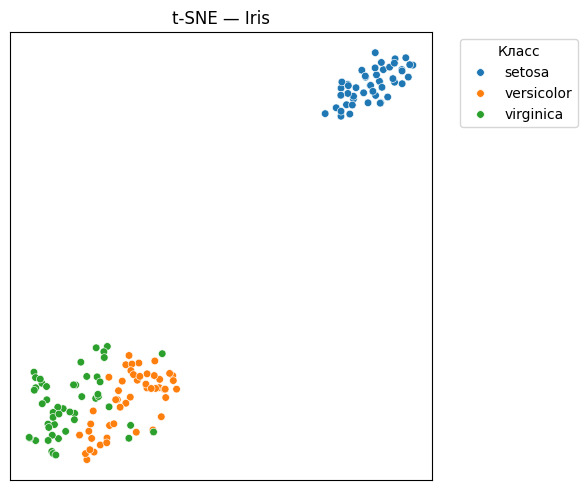

t-SNE: внутрикласс.=3.512, межкласс.=22.740, ratio=6.475


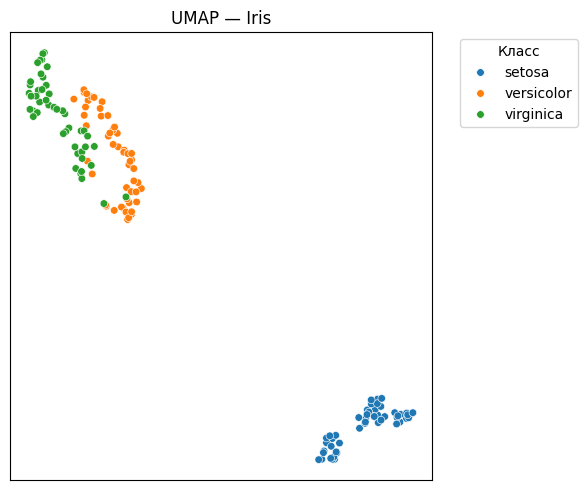

UMAP: внутрикласс.=1.862, межкласс.=11.935, ratio=6.411


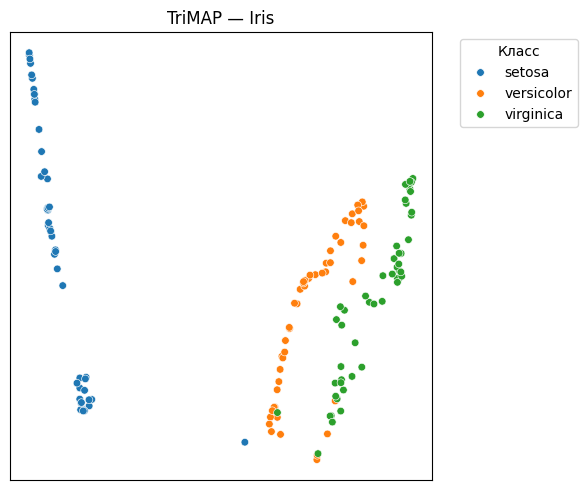

TriMAP: внутрикласс.=11.708, межкласс.=59.458, ratio=5.078


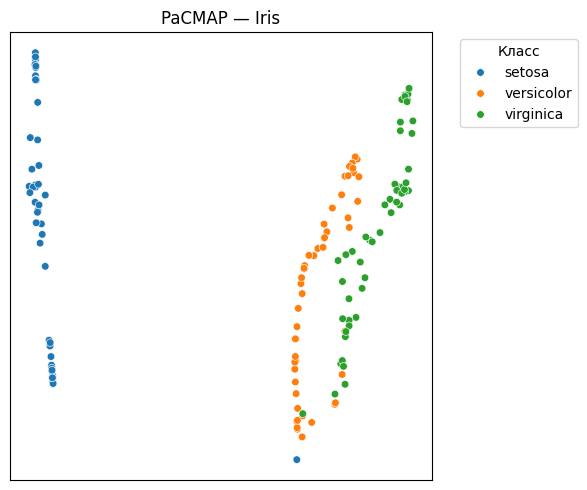

PaCMAP: внутрикласс.=3.470, межкласс.=17.674, ratio=5.093


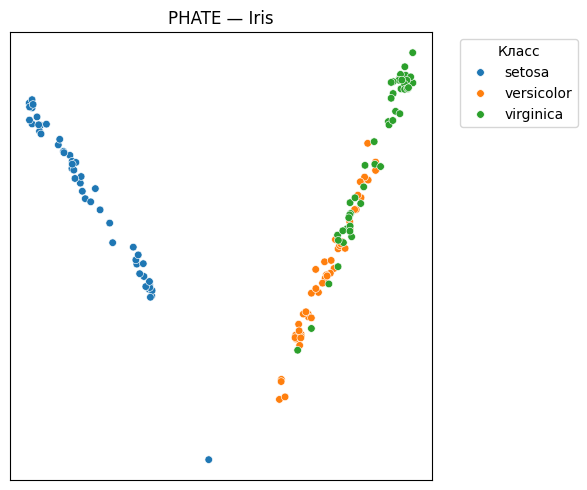

PHATE: внутрикласс.=0.026, межкласс.=0.121, ratio=4.610


In [9]:
iris_target_names = [iris.target_names[i] for i in y_iris]

iris_scores = {}
for X_emb, name in zip(X_list_iris, names_iris):
    same, diff, ratio = separation_score(X_emb, y_iris)
    iris_scores[name] = ratio
    plot_embedding(X_emb, iris_target_names, f'{name} — Iris')
    print(f'{name}: внутрикласс.={same:.3f}, межкласс.={diff:.3f}, ratio={ratio:.3f}')

Все 5 методов хорошо разделяют Iris. Setosa изолирована во всех случаях это линейно-отделимый класс. Versicolor и Virginica сложнее разделить. UMAP и t-SNE дают наибольшее визуальное расстояние между классами

## (Датасет Job Status) применение всех методов

In [11]:
X_list_job = []
names_job = []

print('t-SNE Jobs Status...')
X_list_job.append(run_tsne(X))
names_job.append('t-SNE')

print('UMAP Jobs Status...')
X_list_job.append(run_umap(X))
names_job.append('UMAP')

print('TriMAP Jobs Status...')
X_list_job.append(run_trimap(X))
names_job.append('TriMAP')

print('PaCMAP Jobs Status...')
X_list_job.append(run_pacmap(X))
names_job.append('PaCMAP')

print('PHATE Jobs Status...')
X_list_job.append(run_phate(X))
names_job.append('PHATE')

print('ok')

t-SNE Jobs Status...
UMAP Jobs Status...
TriMAP Jobs Status...


PaCMAP Jobs Status...
PHATE Jobs Status...
    SGD-MDS may not have converged: stress changed by 5.7% in final iterations. Consider increasing n_iter or adjusting learning_rate.
ok


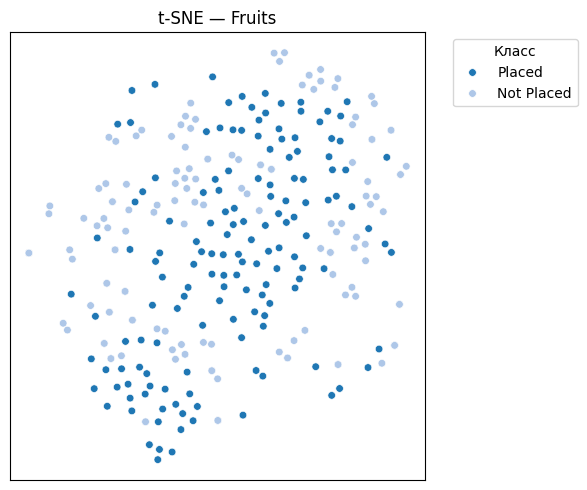

t-SNE: внутрикласс.=124.334, межкласс.=127.709, ratio=1.027


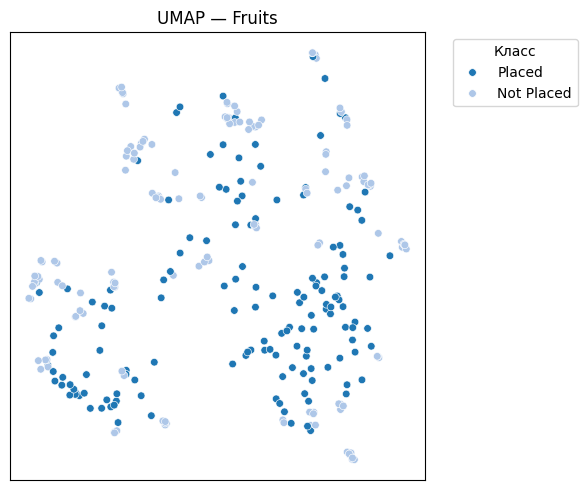

UMAP: внутрикласс.=3.527, межкласс.=3.778, ratio=1.071


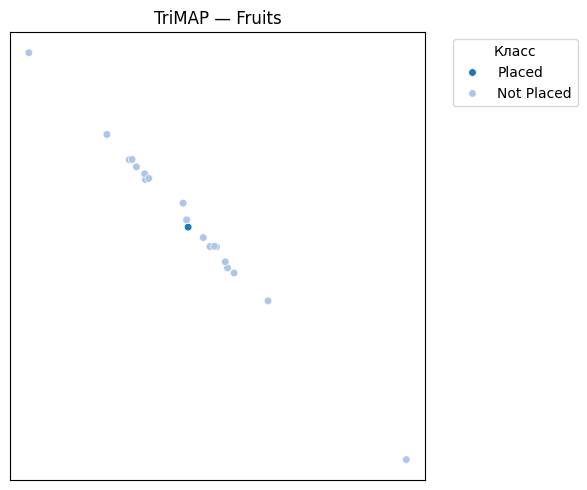

TriMAP: внутрикласс.=789124.188, межкласс.=819488.375, ratio=1.038


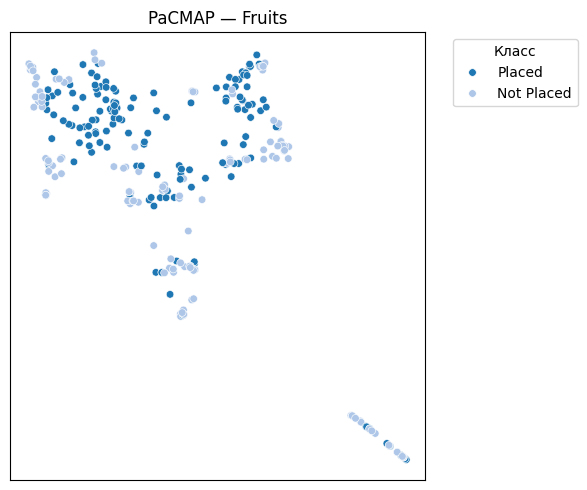

PaCMAP: внутрикласс.=7.319, межкласс.=7.834, ratio=1.070


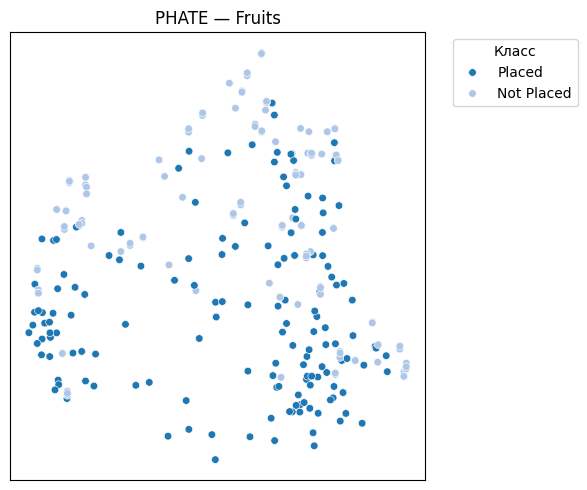

PHATE: внутрикласс.=0.065, межкласс.=0.067, ratio=1.024


In [ ]:
job_labels = [label_names[i] for i in y]

job_scores = {}
for X_emb, name in zip(X_list_job, names_job):
    same, diff, ratio = separation_score(X_emb, y)
    job_scores[name] = ratio
    plot_embedding(X_emb, job_labels, f'{name} — Jobs Status', palette='tab20')
    print(f'{name}: внутрикласс.={same:.3f}, межкласс.={diff:.3f}, ratio={ratio:.3f}')

На Job Placement разделение классов значительно хуже, чем на Iris 20 классов при 6 признаках. Все методы дают схожий примерно результат - классы перекрываются. UMAP и PaCMAP показывают лучший баланс сохранения локальной и глобальной структуры. PHATE образует размытые диффузионные потоки без чётких кластеров.

## Итоговое сравнение методов

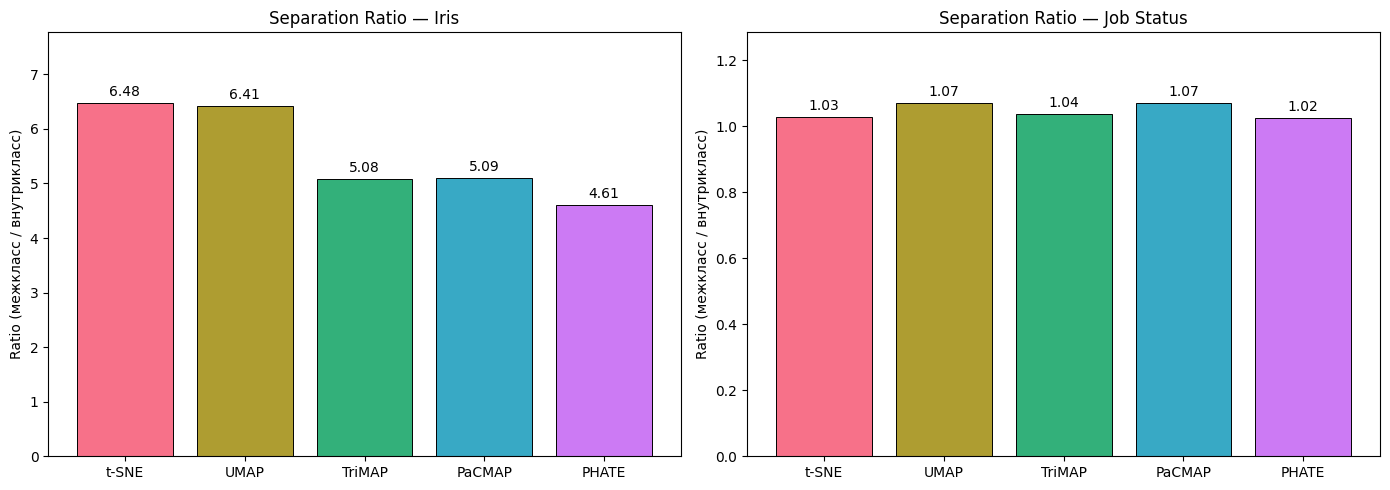

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scores, ds_name in zip(
    axes,
    [iris_scores, job_scores],
    ['Iris', 'Job Status']
):
    names = list(scores.keys())
    ratios = list(scores.values())
    colors = sns.color_palette('husl', len(names))
    bars = ax.bar(names, ratios, color=colors, edgecolor='black', linewidth=0.7)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
    ax.set_title(f'Separation Ratio — {ds_name}', fontsize=12)
    ax.set_ylabel('Ratio (межкласс / внутрикласс)')
    ax.set_ylim(0, max(ratios) * 1.2)

plt.tight_layout()
plt.show()

Iris. Все 5 методов хорошо разделяют классы. Лучший ratio у t-SNE и UMAP. PHATE даёт интересную траекторную структуру, но уступает по ratio

Job Status. Разделение слабее. UMAP и PaCMAP показывают наилучший баланс между локальной и глобальной структурой
